## Inertial Measurement Units (IMUs)

IMUs are electronic devices developed to quantify the change in velocity in a small mass of a known weight. 
The mass is attached to a spring, with a known spring constant, but free to move otherwise

<div style="text-align: center;">
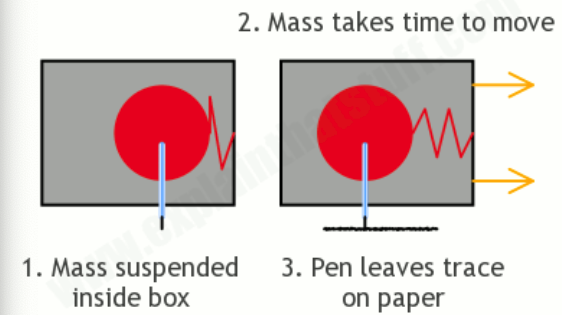
</div>

When the accelerometer is at rest, the mass is at rest and not moving. 

When the accelerometer moves, the mass will move against the spring, changing its length. We can measure the change in length by tracking the position of the mass. 

As it turns out, if you know the spring deformation and the constant, then you can estimate the force applied to the spring using a principle known as Hooke's law.

$$
F = kh
$$

Where
- $F$ is the force applied to the spring
- $k$ is the spring constant 
- $h$ is the displacement in the spring

Now, we can use Newton's law to measure the acceleration in the mass

$$
a = \frac{F}{m}
$$

Where
- $a$ acceleration observed by the mass
- $F$ force applied to the spring
- $m$ known weight of the mass


Modern accelerometers do not use mass and springs as these are prone to fail. Rather, they are based on an electromagnetic phenomenon known as **Hall's Effect**, allowing them to be very small and precise. Moreover, they can be organized in such a way that a single device can measure acceleration in three dimensions.

## Gait Analysis from IMUs

<div style="text-align: center;">
<img src='gaitIMUs.png' alt='gait IMUs'>
</div>


In this notebook, we will use data collected with an Inertial Measurement Unit (IMU) located around the center of mass during gait. We will study a simple application of linear regression to gait analysis. 

The overall objectives are to learn how to 
- Visualize acceleration data recorded during gait 
- Detect gait events from acceleration data 
- Re-structure your data using interpolation to analyze relevant gait biomechanics


### Analysis Pipeline

In this notebook, you will follow the same steps commonly used in biomechanics research:

1. Inspect raw IMU data  
2. Remove physiologically irrelevant frequencies  
3. Detect gait events (heel strikes)  
4. Segment the signal into strides  
5. Normalize strides from 0–100%  
6. Compute ensemble averages  
7. Extract clinically meaningful metrics  

By the end of this notebook, you will understand how raw sensor data becomes interpretable biomechanical information.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d

In [40]:
#the data contains the time vector and acceleration (x,y, and z) 
data = pd.read_csv('data/accelerationSteps.csv', index_col=None)
data.head()

,time,z,y,x
0,0.000000,-1.063303,-0.129520,-0.508230
1,0.010005,-1.040474,0.026074,-0.266110
2,0.020010,-1.035832,0.170286,-0.062972
3,0.030015,-1.064030,0.352063,0.209522
4,0.040020,-1.110660,0.475886,0.433908


Text(0, 0.5, 'z-Acceleration')

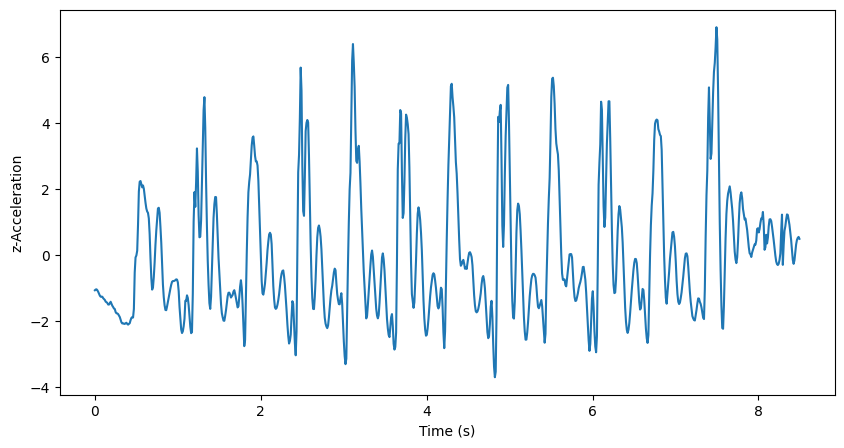

In [41]:

plt.figure(figsize=(10,5))
plt.plot(data['time'], data['z'])
plt.xlabel('Time (s)')
plt.ylabel('z-Acceleration')

As you can see, this signal has some drift (red line) and the peaks of acceleration are not well defined (double peaks). We need to remove elements from the acceleration signal that are not useful for our analysis. 

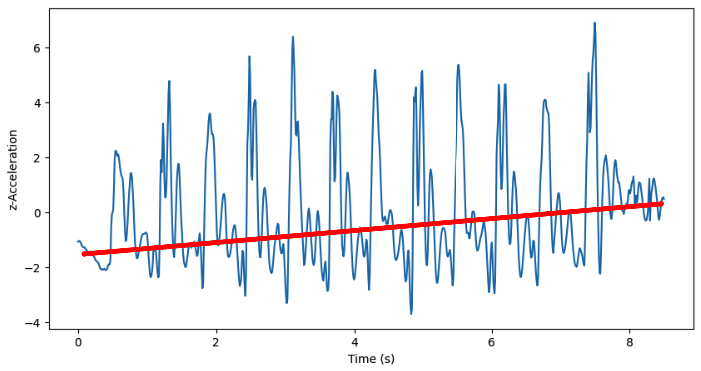


Filtering your data ensures that the signal reflects human movement rather than sensor drift or noise. You should have an understanding of the frequencies of interest to your problem before filtering.

The average sampling rate is 99.95002498750583


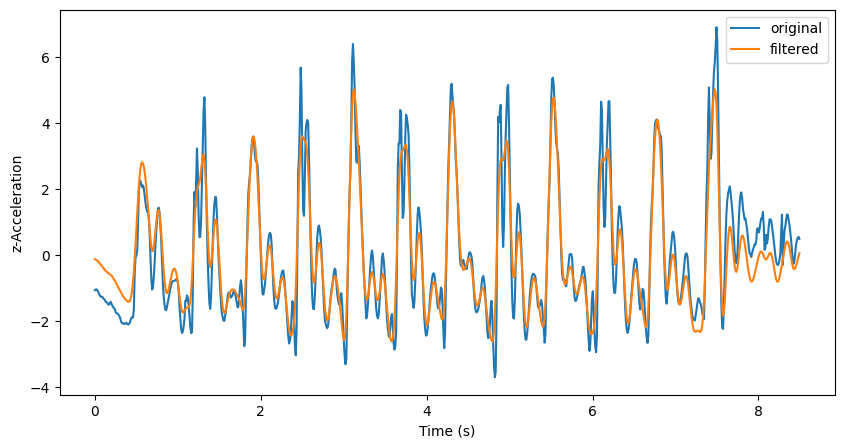

In [42]:
#we will filter (remove parts that we don't want) the signal 
#for gait, we can remove all components that are not physiologically relevant. We will remove components below 0.5 Hz and above 7 Hz
#note that for other activities, like running, these values need to be adjusted. 

#finding the sampling rate (ie. how many samples in a second)
fs = 1/np.median(np.diff(data['time']))
print(f'The average sampling rate is {fs}')

#designing and applying a filter with the desired cutoffs
low_cf = 0.5 / (fs/2)
high_cf = 7 / (fs/2)
b, a = butter(2, [low_cf, high_cf], btype='bandpass')
z_filt = filtfilt(b,a,data['z'])
time = data['time'].values

plt.figure(figsize=(10,5))
plt.plot(time, data['z'], label='original')
plt.plot(time, z_filt, label='filtered')
plt.xlabel('Time (s)')
plt.ylabel('z-Acceleration')
plt.legend()

Now, we can use the acceleration data to detect steps. This can be achieved by detecting the different heel strikes in the acceleration data. The heel strikes correspond to the peaks in the acceleration signal; this is the moment when the maximum acceleration (your heel hits the ground) occurs. 


We can find the peak using the `find_peaks` function from the `scipy` library. 


Text(0, 0.5, 'z-Acceleration')

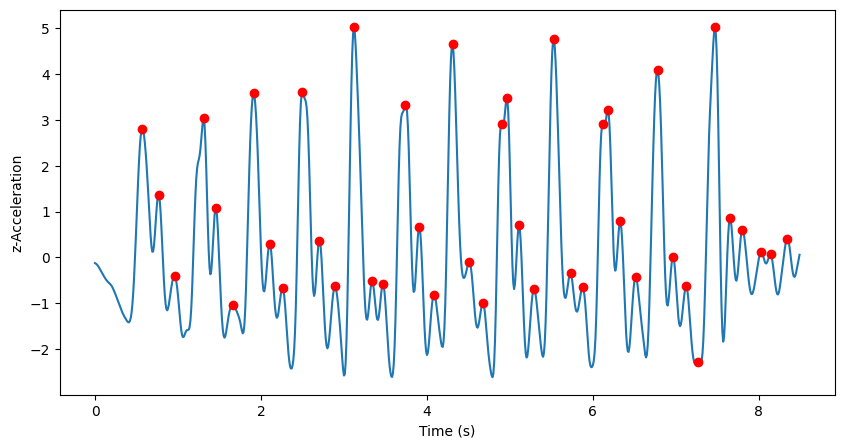

In [23]:
peaks, val = find_peaks(z_filt)
plt.figure(figsize=(10,5))
plt.plot(time, z_filt)
plt.plot(time[peaks], z_filt[peaks], 'o', color = 'red')
plt.xlabel('Time (s)')
plt.ylabel('z-Acceleration')

As you can see, this function found **ALL** the peaks in the data, which is not very useful. 

We can restrict the peaks by using information about the peak height and time between peaks. 

In this case, we only want peaks above 1, and want peaks that are at least 0.5 seconds apart.

The `distance` must be given in index, not in time, so we need to transform the 0.5s to index, as

```python
distance = int(0.5 * fs)
```

Text(0, 0.5, 'z-Acceleration')

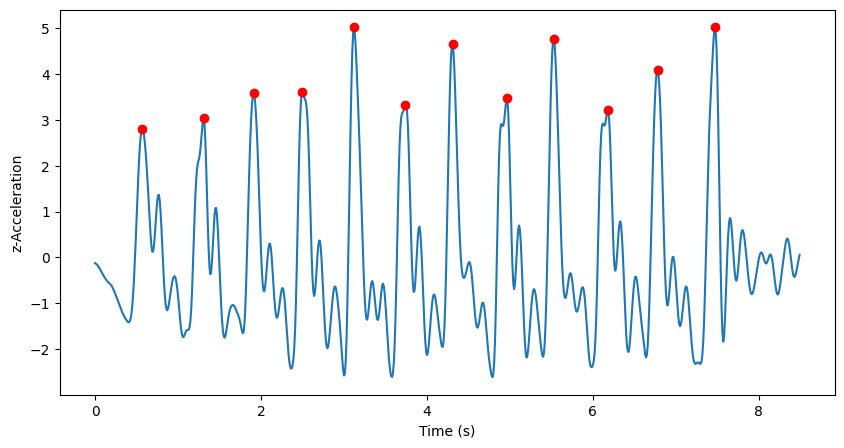

In [43]:
distance = int(0.5 * fs)
height = np.mean(z_filt) + np.std(z_filt)
peaks, val = find_peaks(z_filt, height=height, distance = distance)
plt.figure(figsize=(10,5))
plt.plot(time, z_filt)
plt.plot(time[peaks], z_filt[peaks], 'o', color = 'red')
plt.xlabel('Time (s)')
plt.ylabel('z-Acceleration')

Great, we found the peaks in the acceleration signal!

Each peak should correspond to a heel strike, so we can visualize what happens during each stride.

⚠️ Important:

A **step** is the movement between opposite feet.  
A **stride** is a full gait cycle (heel strike → next heel strike of the same foot).

In this notebook, we analyze strides because they represent the complete biomechanical pattern.



<div style="text-align: center;">
<img src='gaitEvents.png' alt='gait IMUs'>
</div>


We can now plot each segment so and analyze each step or stride.

Text(0, 0.5, 'z-Acceleration')

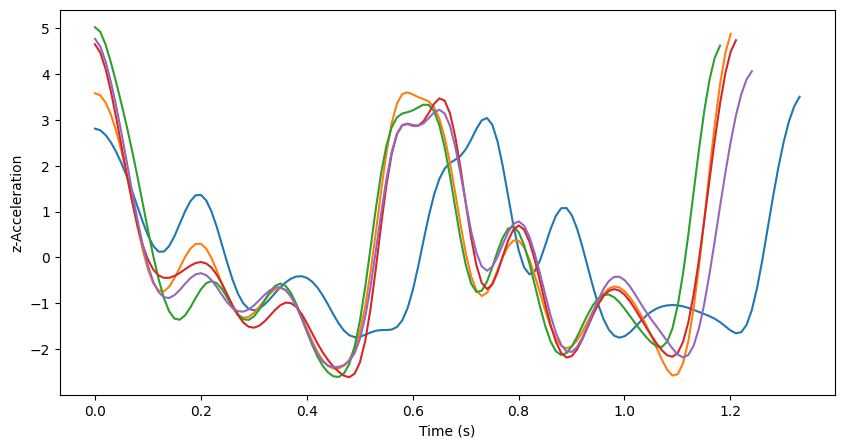

In [44]:
#lets plot the acceleration recorded at each stride

plt.figure(figsize=(10,5))
segments = []
for i in range(0,len(peaks)-2,2):
    start_index = peaks[i]
    end_index = peaks[i+2]

    duration = time[start_index:end_index] 
    #assure that each step last at least 0.5 secods
    if (duration[-1] - duration[0])>=0.5:
        segments.append(z_filt[start_index:end_index])
        plt.plot(duration-duration[0], segments[-1])

plt.xlabel('Time (s)')
plt.ylabel('z-Acceleration')


#### Why normalization is necessary

The steps have a slightly different duration, so we cannot analyze how the acceleration changes during gait...


The solution is to change our x-axis from time (in seconds) to stride phase (in %) so that all the strides occur between 0 and 100% of the stride phase.

We will use linear interpolation to solve this problem. That is, we will create a new time vector with 101 elements (from 0 to 100) and will use linear regression to find the values of the z-acceleration for the new time ($x$) vector using our measurements ($x0$ and $x1$)

<div style="text-align: center;">
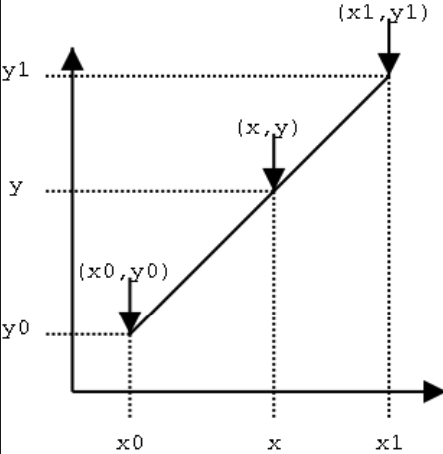
</div>





Text(0, 0.5, 'z-Acceleration')

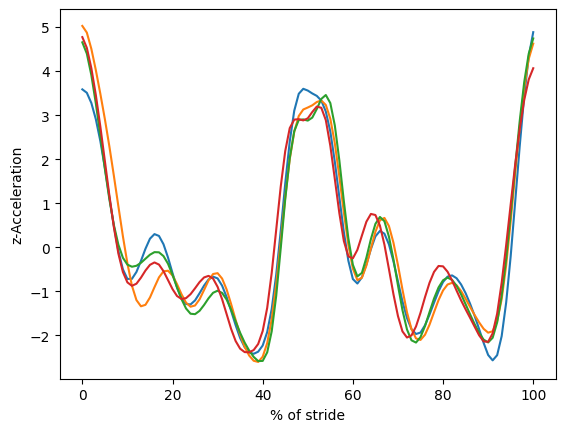

In [45]:
#time normalization 


segments_normalized = []
segments = []
for i in range(0,len(peaks)-2,2):
    if i == 0:
        pass
    else:
        start_index = peaks[i]
        end_index = peaks[i+2]
    
        duration = time[start_index:end_index] 
        #assure that each step lasts at least 0.5 seconds
        if (duration[-1] - duration[0])>=0.5:
    
            original = np.linspace(0,100,len(duration))
            target = np.linspace(0, 100, 101)
            iterpolator = interp1d(original, z_filt[start_index:end_index],kind='linear')
            segments_normalized.append(iterpolator(target))
            plt.plot(target, segments_normalized[-1])

plt.xlabel("% of stride")
plt.ylabel('z-Acceleration')

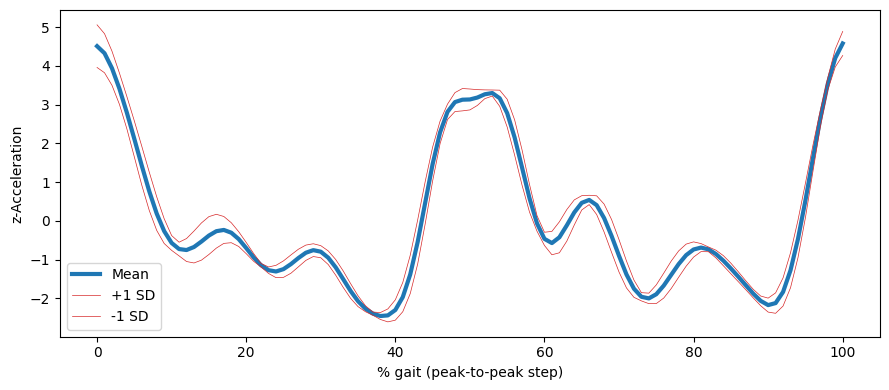

In [46]:
#now we can use an ensemble filter to minimize noise in the signal
segments_normalized = np.array(segments_normalized)
normalized_time = np.linspace(0, 100, 101)

plt.figure(figsize=(9, 4))

# plot individual steps lightly (shows variability)
mean_gait = segments_normalized.mean(axis=0)
std_gait = segments_normalized.std(axis=0)
# plot mean and SD band as lines (students can see it clearly)
plt.plot(normalized_time, mean_gait, linewidth=3, label="Mean")
plt.plot(normalized_time, mean_gait + std_gait, color = "tab:red", linewidth=0.5, label="+1 SD")
plt.plot(normalized_time, mean_gait - std_gait, color = "tab:red", linewidth=0.5, label="-1 SD")

plt.xlabel("% gait (peak-to-peak step)")
plt.ylabel("z-Acceleration")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
#from the acceleration signal, we can also obtain useful information, as:

#number of steps:
NumberOfStep = len(peaks)
print(f'Number of Steps = {NumberOfStep}')

#cadence
Duration = time[peaks[-1]] - time[peaks[0]]
print(f'Cadence = {(NumberOfStep/Duration)*60:.3f} steps per minute')

#average step duration
StepDuration = np.diff(time[peaks])
print(f'Average Step Duration = {np.mean(StepDuration):.3f} seconds')

#step duration variability
print(f'Step Duration Variability = {np.std(StepDuration):.3f} seconds')

#Average Stride duration
StrideDuration = np.diff(time[peaks[::2]])
print(f'Average Step Duration = {np.mean(StrideDuration):.3f} seconds')

#Stride duration variability
print(f'Step Duration Variability = {np.std(StrideDuration):.3f} seconds')



Number of Steps = 12
Cadence = 104.295 steps per minute
Average Step Duration = 0.628 seconds
Step Duration Variability = 0.050 seconds
Average Step Duration = 1.243 seconds
Step Duration Variability = 0.053 seconds


### Why Does This Matter?

Measures such as cadence and stride variability are some of the strongest predictors of:

- Fall risk  
- Neurological impairment  
- Aging-related mobility decline  
- Parkinsonian gait  

The exact workflow you used today is applied in modern digital health research.


## Key Takeaways

In this notebook, you transformed raw IMU data into meaningful biomechanical information.

You learned how to:

- Remove physiologically irrelevant components from a signal  
- Detect gait events from acceleration data  
- Segment continuous data into discrete strides  
- Normalize strides from 0–100% of the gait cycle  
- Compute ensemble averages and variability  
- Extract clinically relevant gait metrics  

This workflow reflects the foundation of modern movement analysis and is widely used in biomechanics, rehabilitation science, and digital health.

Most importantly, remember:

**Sensors do not measure biomechanics — analysis creates biomechanics.**

The quality of your interpretation depends on the quality of your signal processing choices.

As wearable technology continues to expand, the ability to convert raw sensor data into meaningful insight will become an increasingly valuable skill for researchers and clinicians alike.

